In [1]:
import sys
from pathlib import Path
import py_dss_interface
import networkx as nx
import pandas as pd

from unit_converter import UnitConverter
from fault import FaultSimulator
from topologia import FeederTopology
from locator import FaultLocator

In [2]:
BASE_DIR = Path("..").resolve()
BASE_DIR

WindowsPath('D:/UFC/LOCALIZACAO-DE-FALTAS/refatorando-codigo/tcc-luis-felipe')

In [3]:
DSS_FILE = BASE_DIR / "data" / "34Bus" / "Run_IEEE34Mod1.dss"
DSS_FILE

WindowsPath('D:/UFC/LOCALIZACAO-DE-FALTAS/refatorando-codigo/tcc-luis-felipe/data/34Bus/Run_IEEE34Mod1.dss')

In [4]:
simulador = FaultSimulator(str(DSS_FILE), origin_bus='800', target_kv=14.37)
simulador.topology.print_circuits_info()


🗺️  RESUMO DA TOPOLOGIA DOS CIRCUITOS MAPEADOS

C_1: L = 42.34 | Q = 4 | seçoes: [L1-L2-L3-L4]
C_2: L = 117.33 | Q = 9 | seçoes: [L1-L2-L3-L5-L6-L7-L24-L9-L12]
C_3: L = 167.69 | Q = 10 | seçoes: [L1-L2-L3-L5-L6-L7-L24-L8-L10-L11]
C_4: L = 159.43 | Q = 12 | seçoes: [L1-L2-L3-L5-L6-L7-L24-L9-L13-L14-L15-L26]
C_5: L = 179.46 | Q = 15 | seçoes: [L1-L2-L3-L5-L6-L7-L24-L9-L13-L14-L15-L27-L25-L16-L28]
C_6: L = 189.23 | Q = 18 | seçoes: [L1-L2-L3-L5-L6-L7-L24-L9-L13-L14-L15-L27-L25-L16-L29-L17-L30-L19]
C_7: L = 189.47 | Q = 19 | seçoes: [L1-L2-L3-L5-L6-L7-L24-L9-L13-L14-L15-L27-L25-L16-L29-L18-L21-L22-L23]
C_8: L = 193.51 | Q = 19 | seçoes: [L1-L2-L3-L5-L6-L7-L24-L9-L13-L14-L15-L27-L25-L16-L29-L17-L30-L20-L31]




In [7]:
simulador = FaultSimulator(str(DSS_FILE), origin_bus='800', target_kv=14.37)

# 3. (Opcional) Imprime o resumo da topologia descoberta automaticamente
# Isso chamará aquele método de print bonito que configuramos na FeederTopology

# 4. Configura os parâmetros da varredura
# Varrendo a linha de 10% em 10%
passo_distancia = 0.30  
passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]  
resistencias_falta = [0.0001]  

# 5. Executa o laço principal da simulação
print("\nIniciando a varredura linear de curtos-circuitos...")

simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)

localizador = FaultLocator(str(DSS_FILE), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()



Iniciando a varredura linear de curtos-circuitos...


Aplicando Filtro MI: 100%|██████████| 12429/12429 [00:02<00:00, 5231.35it/s]


In [8]:
localizador.df

,va_r,va_i,vb_r,vb_i,vc_r,vc_i,ia_r,ia_i,ib_r,ib_i,...,circuito_5_line,circuito_6_d,circuito_6_line,circuito_7_d,circuito_7_line,circuito_8_d,circuito_8_line,linha_estimada,dist_estimada,erro_percentual
0,14176.031953,-601.531341,-7328.570585,-12952.706480,-7328.288598,13192.202526,163764.037424,-177498.929473,-20.412232,-29.766292,...,l1,50.000077,l1,50.000076,l1,50.000076,l1,l1,50.000078,1.349468e-07
1,15085.867327,-248.598742,-7595.239576,-11979.652859,-7556.137927,12824.176241,37.038968,-3.123443,-235312.101775,-49969.648684,...,l1,50.000064,l1,50.000064,l1,50.000063,l1,l1,50.000066,1.139939e-07
2,14883.032194,130.806446,-7759.274793,-12941.356548,-6572.701340,12571.814313,39.403020,-4.366007,-17.697516,-28.039087,...,l1,50.000060,l1,50.000060,l1,50.000060,l1,l1,50.000061,1.049866e-07
3,14566.162418,-1482.597008,-7019.038442,-11589.948607,-7547.159834,13072.549048,278483.528904,-45598.967910,-278466.570059,45544.394987,...,l1,50.000058,l1,50.000058,l1,50.000058,l1,l1,50.000058,1.000220e-07
4,15094.713484,-0.297325,-8441.899313,-11878.511205,-6652.821071,11878.800104,56.597975,-10.213400,-181843.573912,-196137.850518,...,l1,50.000054,l1,50.000054,l1,50.000053,l1,l1,50.000054,9.347661e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12424,15094.769577,-0.423936,-7547.632155,-13071.457718,-7547.231236,13072.370093,40.443220,-3.996684,-212.778042,-80.670289,...,l27,48594.264000,l26,52272.786772,l27,52274.343777,l27,l27,52274.426735,-1.121393e+01
12425,15094.769551,-0.423803,-7547.632098,-13071.458383,-7547.231229,13072.370228,40.449896,-4.001790,-212.633222,-80.635127,...,l27,48594.264000,l26,52303.732276,l27,52305.292086,l27,l27,52305.375193,-1.124692e+01
12426,15094.769524,-0.423670,-7547.632042,-13071.459047,-7547.231221,13072.370363,40.456562,-4.006887,-212.488636,-80.600026,...,l27,48594.264000,l26,52334.647037,l27,52336.209771,l27,l27,52336.293035,-1.127996e+01
12427,15094.769498,-0.423537,-7547.631986,-13071.459710,-7547.231214,13072.370498,40.463255,-4.011998,-212.344296,-80.564985,...,l27,48594.264000,l26,52365.531145,l27,52367.096922,l27,l27,52367.180347,-1.131305e+01


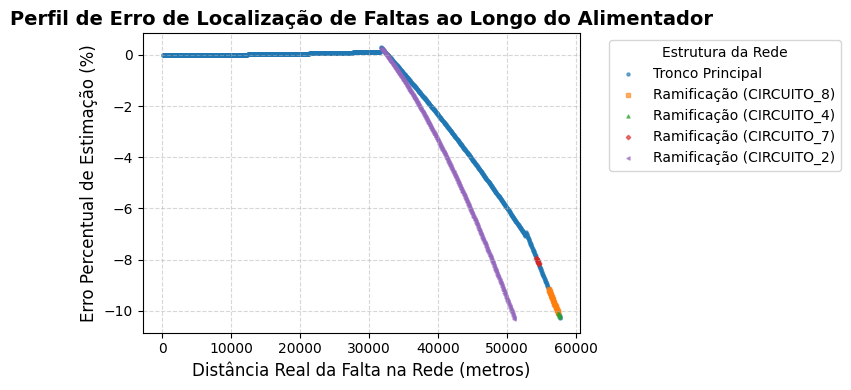

In [17]:

import matplotlib.pyplot as plt

"""
Gera um gráfico do erro percentual em função da distância.
Plota primeiro o tronco principal e depois as ramificações exclusivas de cada circuito.
"""
plt.figure(figsize=(8, 4))

# 1. Ordena os circuitos do maior para o menor (em quantidade de seções)
# O maior será naturalmente o "tronco principal"
circuitos_ordenados = sorted(localizador.topology.main_circuits.items(), key=lambda item: len(item[1]), reverse=True)

# Conjunto para rastrear quais linhas já foram plotadas
linhas_plotadas = set()

# Paleta de marcadores para diferenciar visualmente os ramais
marcadores = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'X']

for idx, (nome_circuito, linhas) in enumerate(circuitos_ordenados):
    # 2. Filtra as linhas: pega apenas as que AINDA NÃO estão no tronco/ramais anteriores
    linhas_do_ramal = [linha for linha in linhas if linha not in linhas_plotadas]
    
    if not linhas_do_ramal:
        continue # Se todas as linhas já foram plotadas (circuito 100% redundante), pula.
        
    # 3. Filtra o DataFrame para pegar as distâncias e erros dessas linhas específicas
    df_ramal = localizador.df[localizador.df['linha_faltosa'].isin(linhas_do_ramal)]
    # Exemplo se quisesse filtrar:
    df_ramal = localizador.df[(localizador.df['linha_faltosa'].isin(linhas_do_ramal)) & (localizador.df['tipo'] == 'at') & (localizador.df['r'] == 0.0001)]
    
    if df_ramal.empty:
        continue
        
    # Define o nome para a legenda
    label_nome = "Tronco Principal" if idx == 0 else f"Ramificação ({nome_circuito.upper()})"
    
    # 4. Plota os dados em gráfico de dispersão (Scatter)
    # Scatter é ideal porque para uma mesma distância temos vários erros (tipos de falta e resistências diferentes)
    plt.scatter(df_ramal['distancia'], df_ramal['erro_percentual'], label=label_nome, marker=marcadores[idx % len(marcadores)], alpha=0.6, s=5)
    
    # 5. Adiciona as linhas desenhadas ao conjunto de bloqueio
    linhas_plotadas.update(linhas_do_ramal)

# Configurações de estética do gráfico
plt.title('Perfil de Erro de Localização de Faltas ao Longo do Alimentador', fontsize=14, fontweight='bold')
plt.xlabel('Distância Real da Falta na Rede (metros)', fontsize=12)
plt.ylabel('Erro Percentual de Estimação (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Coloca a legenda fora do gráfico para não sobrepor os dados
plt.legend(title='Estrutura da Rede', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Ajusta as margens automaticamente

# # Salva o gráfico ou exibe na tela
# if save_path:
#     Path(save_path).parent.mkdir(parents=True, exist_ok=True)
#     plt.savefig(save_path, dpi=300, bbox_inches='tight')
#     print(f"📊 Gráfico gerado e salvo com sucesso em: {save_path}")
# else:
plt.show()

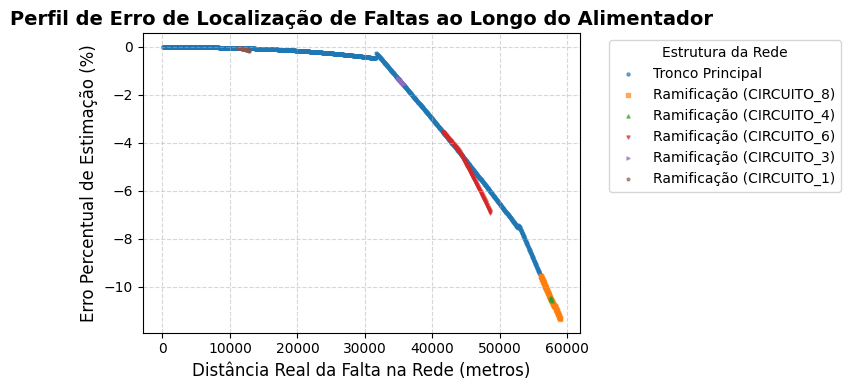

In [15]:

import matplotlib.pyplot as plt

"""
Gera um gráfico do erro percentual em função da distância.
Plota primeiro o tronco principal e depois as ramificações exclusivas de cada circuito.
"""
plt.figure(figsize=(8, 4))

# 1. Ordena os circuitos do maior para o menor (em quantidade de seções)
# O maior será naturalmente o "tronco principal"
circuitos_ordenados = sorted(localizador.topology.main_circuits.items(), key=lambda item: len(item[1]), reverse=True)

# Conjunto para rastrear quais linhas já foram plotadas
linhas_plotadas = set()

# Paleta de marcadores para diferenciar visualmente os ramais
marcadores = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'X']

for idx, (nome_circuito, linhas) in enumerate(circuitos_ordenados):
    # 2. Filtra as linhas: pega apenas as que AINDA NÃO estão no tronco/ramais anteriores
    linhas_do_ramal = [linha for linha in linhas if linha not in linhas_plotadas]
    
    if not linhas_do_ramal:
        continue # Se todas as linhas já foram plotadas (circuito 100% redundante), pula.
        
    # 3. Filtra o DataFrame para pegar as distâncias e erros dessas linhas específicas
    df_ramal = localizador.df[localizador.df['linha_faltosa'].isin(linhas_do_ramal)]
    # Exemplo se quisesse filtrar:
    df_ramal = localizador.df[(localizador.df['linha_faltosa'].isin(linhas_do_ramal)) & (localizador.df['tipo'] == 'bt') & (localizador.df['r'] == 0.0001)]
    
    if df_ramal.empty:
        continue
        
    # Define o nome para a legenda
    label_nome = "Tronco Principal" if idx == 0 else f"Ramificação ({nome_circuito.upper()})"
    
    # 4. Plota os dados em gráfico de dispersão (Scatter)
    # Scatter é ideal porque para uma mesma distância temos vários erros (tipos de falta e resistências diferentes)
    plt.scatter(df_ramal['distancia'], df_ramal['erro_percentual'], label=label_nome, marker=marcadores[idx % len(marcadores)], alpha=0.6, s=5)
    
    # 5. Adiciona as linhas desenhadas ao conjunto de bloqueio
    linhas_plotadas.update(linhas_do_ramal)

# Configurações de estética do gráfico
plt.title('Perfil de Erro de Localização de Faltas ao Longo do Alimentador', fontsize=14, fontweight='bold')
plt.xlabel('Distância Real da Falta na Rede (metros)', fontsize=12)
plt.ylabel('Erro Percentual de Estimação (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Coloca a legenda fora do gráfico para não sobrepor os dados
plt.legend(title='Estrutura da Rede', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Ajusta as margens automaticamente

# # Salva o gráfico ou exibe na tela
# if save_path:
#     Path(save_path).parent.mkdir(parents=True, exist_ok=True)
#     plt.savefig(save_path, dpi=300, bbox_inches='tight')
#     print(f"📊 Gráfico gerado e salvo com sucesso em: {save_path}")
# else:
plt.show()